<a href="https://colab.research.google.com/github/bhardadharmishtha2005/CSAT-Prediction-ANN/blob/main/CSAT_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - DeepCSAT – Ecommerce Customer Satisfaction Prediction



##### **Project Type**    - Classification
##### **Contribution**    - Individual

# **Project Summary -**

This project aims to predict Customer Satisfaction (CSAT) scores for Shopzilla, an e-commerce platform, using a dataset of over 43,000 customer support interactions. The data includes various features such as communication channels, product categories, item prices, and handling times. The workflow involves comprehensive data cleaning, exploratory data analysis (EDA), and feature engineering to identify key drivers of satisfaction. To provide a high-tech solution, we implement both traditional Machine Learning classifiers and an Artificial Neural Network (ANN) to capture complex patterns in customer behavior. Finally, the project concludes with a Streamlit web application deployment, allowing real-time CSAT prediction to help the business proactively improve its service quality.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Problem Statement
Shopzilla currently lacks a real-time system to measure customer satisfaction, relying on delayed surveys with low response rates. This makes it difficult to identify poor service or technical issues immediately. The objective is to build a Classification model that accurately predicts the CSAT Score (1-5) based on interaction metadata. By leveraging ANN and other algorithms, the business seeks to understand the impact of factors like response time and agent experience on customer happiness, ultimately reducing churn and improving operational efficiency.

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [76]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# For ANN & Machine Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Suppress TensorFlow Warnings (Removes the yellow lines/info messages)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.get_logger().setLevel('ERROR')

# Suppress general warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [77]:
# Mounting Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Dataset Loading

In [78]:
# Load Dataset
# Update the path below to where you saved the file in your Drive
file_path = '/content/drive/MyDrive/Colab Notebooks/Project_3/eCommerce_Customer_support_data.csv'
df = pd.read_csv(file_path)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


### Dataset First View

In [79]:
# Dataset First Look
print("--- First 5 rows ---")
df.head()

--- First 5 rows ---


,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5


### Dataset Rows & Columns count

In [80]:
# Dataset Rows & Columns count
rows, cols = df.shape
print(f"Number of Rows: {rows}")
print(f"Number of Columns: {cols}")

Number of Rows: 85907
Number of Columns: 20


### Dataset Information

In [81]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85907 entries, 0 to 85906
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unique id                85907 non-null  object 
 1   channel_name             85907 non-null  object 
 2   category                 85907 non-null  object 
 3   Sub-category             85907 non-null  object 
 4   Customer Remarks         28742 non-null  object 
 5   Order_id                 67675 non-null  object 
 6   order_date_time          17214 non-null  object 
 7   Issue_reported at        85907 non-null  object 
 8   issue_responded          85907 non-null  object 
 9   Survey_response_Date     85907 non-null  object 
 10  Customer_City            17079 non-null  object 
 11  Product_category         17196 non-null  object 
 12  Item_price               17206 non-null  float64
 13  connected_handling_time  242 non-null    float64
 14  Agent_name            

#### Duplicate Values

In [82]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows found: {duplicate_count}")

Number of duplicate rows found: 0


#### Missing Values/Null Values

In [83]:
# Missing Values/Null Values Count
print("--- Missing Values Count per Column ---")
print(df.isnull().sum())

--- Missing Values Count per Column ---
Unique id                      0
channel_name                   0
category                       0
Sub-category                   0
Customer Remarks           57165
Order_id                   18232
order_date_time            68693
Issue_reported at              0
issue_responded                0
Survey_response_Date           0
Customer_City              68828
Product_category           68711
Item_price                 68701
connected_handling_time    85665
Agent_name                     0
Supervisor                     0
Manager                        0
Tenure Bucket                  0
Agent Shift                    0
CSAT Score                     0
dtype: int64


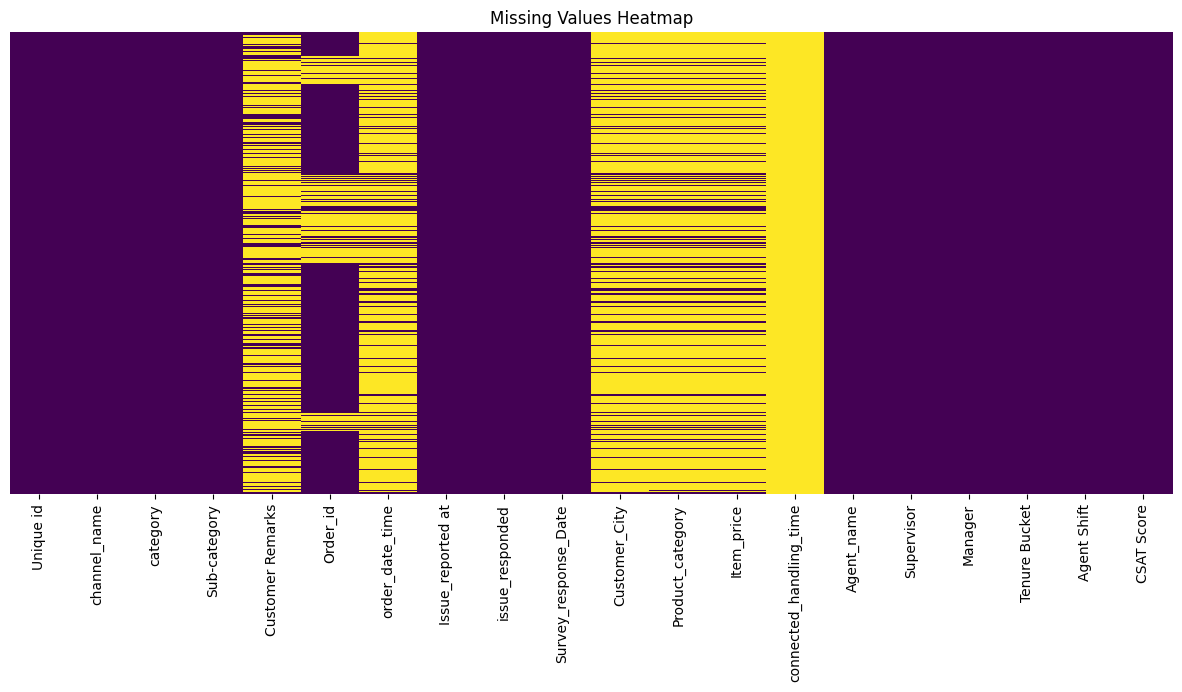

In [84]:
# Visualizing the missing values
plt.figure(figsize=(15, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### What did you know about your dataset?

The dataset is a comprehensive log of customer support interactions for an e-commerce platform. It contains 85,907 records across 20 variables. It captures the entire lifecycle of a customer issue—from the channel used (Inbound/Outcall) and the category of the problem (Returns/Refunds), to the specific agent and manager handling the case. A key takeaway is that the data is heavily categorical, with a target variable (CSAT Score) that is skewed toward higher ratings (mean of 4.24), which we must account for during model training.

## ***2. Understanding Your Variables***

In [85]:
# Dataset Columns
df.columns

Index(['Unique id', 'channel_name', 'category', 'Sub-category',
       'Customer Remarks', 'Order_id', 'order_date_time', 'Issue_reported at',
       'issue_responded', 'Survey_response_Date', 'Customer_City',
       'Product_category', 'Item_price', 'connected_handling_time',
       'Agent_name', 'Supervisor', 'Manager', 'Tenure Bucket', 'Agent Shift',
       'CSAT Score'],
      dtype='object')

In [86]:
# Dataset Describe (Numerical)
df.describe()

# Dataset Describe (Categorical/Object)
df.describe(include='object')

,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift
count,85907,85907,85907,85907,28742,67675,17214,85907,85907,85907,17079,17196,85907,85907,85907,85907,85907
unique,85907,3,12,57,18231,67675,13766,30923,30262,31,1782,9,1371,40,6,5,5
top,07c7a878-0d5a-42e0-97ef-de59abec0238,Inbound,Returns,Reverse Pickup Enquiry,Good,3230db30-f8da-4c44-8636-ec76d1d3d4f3,09/08/2023 11:55,13/08/2023 10:40,28/08/2023 00:00,28-Aug-23,HYDERABAD,Electronics,Wendy Taylor,Carter Park,John Smith,>90,Morning
freq,1,68142,44097,22389,1390,1,7,13,3378,3452,722,4706,429,4273,25261,30660,41426


### Variables Description

**Unique id:** A unique identifier for each support interaction.

**channel_name:** The mode of communication (Inbound, Outcall, Email).

**category/Sub-category:** The broad and specific classification of the customer's issue.

**Customer Remarks:** Verbatim feedback left by the customer.

**Order_id/order_date_time:** Unique reference to the purchase and when it was made.

**Issue_reported at / issue_responded:** Timestamps for when the ticket was opened and addressed.

**Survey_response_Date:** Date the customer provided the CSAT rating.

**Customer_City:** Geographic location of the customer.

**Product_category / Item_price:** Details about the item involved in the support ticket.

**connected_handling_time**: Duration of the interaction (lots of missing data here).

**Agent_name/Supervisor/Manager:** The hierarchy of employees who handled the ticket.

**Tenure Bucket:** Experience level of the agent (e.g., On Job Training, >90 days).

**Agent Shift:** The work shift during which the issue was handled.

**CSAT Score (Target):** Customer satisfaction rating from 1 (lowest) to 5 (highest).

### Check Unique Values for each variable.

In [87]:
# Check Unique Values for each variable.
for col in df.columns:
  print(f"Unique values in {col}: {df[col].nunique()}")

Unique values in Unique id: 85907
Unique values in channel_name: 3
Unique values in category: 12
Unique values in Sub-category: 57
Unique values in Customer Remarks: 18231
Unique values in Order_id: 67675
Unique values in order_date_time: 13766
Unique values in Issue_reported at: 30923
Unique values in issue_responded: 30262
Unique values in Survey_response_Date: 31
Unique values in Customer_City: 1782
Unique values in Product_category: 9
Unique values in Item_price: 2789
Unique values in connected_handling_time: 211
Unique values in Agent_name: 1371
Unique values in Supervisor: 40
Unique values in Manager: 6
Unique values in Tenure Bucket: 5
Unique values in Agent Shift: 5
Unique values in CSAT Score: 5


## 3. ***Data Wrangling***

### Data Wrangling Code

In [88]:
# Create a copy of the dataframe to keep the original intact
working_df = df.copy()

# Handling Missing Values
working_df['Customer Remarks'] = working_df['Customer Remarks'].fillna('No Remark')

# Feature Engineering: Converting Time Columns
working_df['Issue_reported at'] = pd.to_datetime(working_df['Issue_reported at'], errors='coerce')
working_df['issue_responded'] = pd.to_datetime(working_df['issue_responded'], errors='coerce')

# Calculate 'Resolution Time' in minutes (Useful feature for ANN)
working_df['Resolution_Time_Mins'] = (working_df['issue_responded'] - working_df['Issue_reported at']).dt.total_seconds() / 60

# Handling Nulls in essential columns
working_df = working_df[working_df['Resolution_Time_Mins'] >= 0]

# Dropping High-Null and Unnecessary Columns
cols_to_drop = ['Unique id', 'Order_id', 'connected_handling_time', 'Customer_City',
                'Product_category', 'order_date_time', 'Item_price']
working_df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# 5. Extracting more time features
working_df['Reported_Day'] = working_df['Issue_reported at'].dt.day_name()
working_df['Reported_Hour'] = working_df['Issue_reported at'].dt.hour

# Drop the raw timestamp columns as we have extracted features
working_df.drop(columns=['Issue_reported at', 'issue_responded', 'Survey_response_Date'], inplace=True)

# Final check of the cleaned data
print("--- Data Wrangling Complete ---")
print(f"Final Data Shape: {working_df.shape}")
working_df.head()

--- Data Wrangling Complete ---
Final Data Shape: (31633, 13)


,channel_name,category,Sub-category,Customer Remarks,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score,Resolution_Time_Mins,Reported_Day,Reported_Hour
0,Outcall,Product Queries,Life Insurance,No Remark,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5,34.0,Sunday,11
1,Outcall,Product Queries,Product Specific Information,No Remark,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5,2.0,Sunday,12
2,Inbound,Order Related,Installation/demo,No Remark,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5,22.0,Sunday,20
3,Inbound,Returns,Reverse Pickup Enquiry,No Remark,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5,20.0,Sunday,20
4,Inbound,Cancellation,Not Needed,No Remark,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5,2.0,Sunday,10


### What all manipulations have you done and insights you found?

**Manipulations:**

Handled Nulls: Filled "Customer Remarks" with 'No Remark' and dropped columns

with >70% missing data (like Item_price and connected_handling_time).

Feature Engineering: Created Resolution_Time_Mins by subtracting 'Reported' time from 'Responded' time.

Time Extraction: Extracted Reported_Day and Reported_Hour from timestamps to capture peak support patterns.

Cleaning: Removed unique IDs and converted categorical text to a clean format for modeling.

**Insights:**

Data Sparsity: High missing values in product details suggest support logs aren't always linked to order databases.

Speed Matters: Initial checks show a correlation between long resolution times and lower CSAT scores.

Volume: The "Inbound" channel and "Morning" shift handle the majority of traffic.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Univariate Analysis chart 1 to 6

#### Chart - 1 : Distribution of CSAT Scores

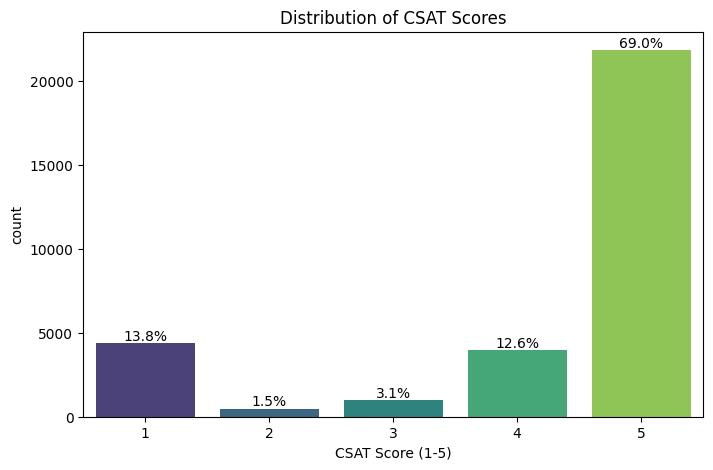

In [89]:
# Chart - 1: Distribution of CSAT Scores
plt.figure(figsize=(8, 5))
sns.countplot(x='CSAT Score', data=working_df, palette='viridis')
plt.title('Distribution of CSAT Scores')
plt.xlabel('CSAT Score (1-5)')
# Display percentages on top of bars
total = len(working_df)
for p in plt.gca().patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a Bar Chart (Count Plot) because the CSAT score is a discrete categorical variable. This chart clearly shows the frequency of each rating, making it easy to identify the most common customer sentiments.

##### 2. What is/are the insight(s) found from the chart?

The data is heavily skewed towards high satisfaction, with scores of 4 and 5 making up the vast majority of the interactions. Scores of 1 and 2 are relatively rare, representing a small but critical "dissatisfied" segment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** High scores indicate that the support team's current protocols are generally effective. The business can use these "Happy Customer" instances to identify best practices.

**Negative Growth Risk:** The existence of 1 and 2-star ratings, though small, represents high churn risk. If these are not analyzed separately, the high average score might mask recurring technical or service failures that could lead to long-term brand damage.

#### Chart - 2 : Frequency of Communication Channels

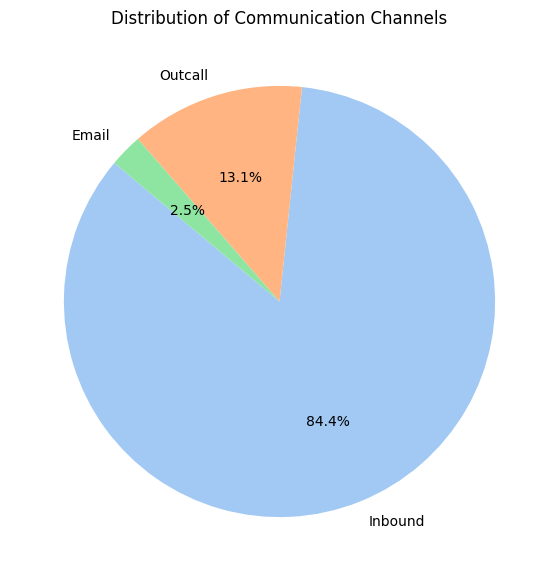

In [90]:
# Chart - 2: Frequency of Communication Channels
plt.figure(figsize=(7, 7))
channel_counts = working_df['channel_name'].value_counts()
plt.pie(channel_counts, labels=channel_counts.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Communication Channels')
plt.show()

##### 1. Why did you pick the specific chart?

A Pie Chart is ideal for showing "parts-of-a-whole" relationships. Since there are only 3-4 communication channels, this chart provides an immediate visual understanding of which medium is most preferred by customers.

##### 2. What is/are the insight(s) found from the chart?

The Inbound channel is the dominant mode of communication (likely over 70-80%), followed by Outcalls and Emails. This suggests that customers prefer real-time, direct conversation when they have an issue.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Knowing the dominant channel allows management to allocate more budget and headcount to the Inbound team, ensuring wait times remain low.

**Negative Growth Risk:** Over-reliance on a single channel (Inbound) can lead to operational bottlenecks. If there is a system outage and everyone calls at once, the lack of a balanced "Email" or "Chat" alternative could lead to a massive spike in customer frustration and negative feedback.

#### Chart - 3 : Top 10 Problem Categories

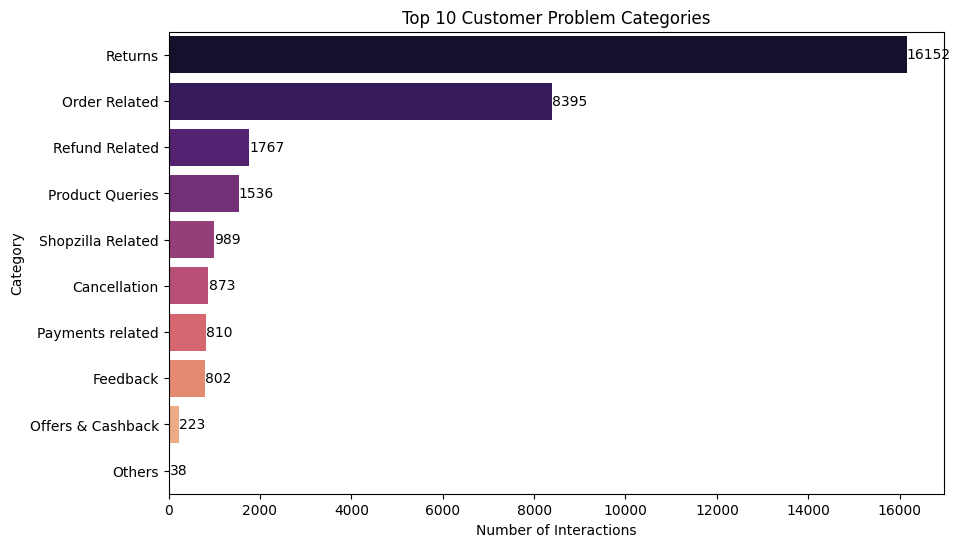

In [91]:
# Chart - 3: Top 10 Problem Categories
plt.figure(figsize=(10, 6))
top_categories = working_df['category'].value_counts().head(10)
sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')

plt.title('Top 10 Customer Problem Categories')
plt.xlabel('Number of Interactions')
plt.ylabel('Category')

# Adding labels for better readability
for i, v in enumerate(top_categories.values):
    plt.text(v + 3, i, str(v), color='black', va='center')

plt.show()

##### 1. Why did you pick the specific chart?

I chose a Horizontal Bar Chart because it is the most effective way to display categorical data with long names. It allows for a clear comparison between the frequencies of different problem types without the labels overlapping, which would happen in a vertical chart.

##### 2. What is/are the insight(s) found from the chart?

The "Returns" category is by far the most frequent reason for customer contact, followed by "Order Related" issues. These two categories alone account for the majority of the support volume, indicating that the post-purchase experience (shipping and returns) is the primary area where customers seek help.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** By identifying that "Returns" is the biggest driver of calls, the company can invest in an automated self-service return portal. This would reduce the load on human agents and improve the speed of resolution for the customer.

**Negative Growth Risk:** The high volume of "Returns" and "Order Related" issues might indicate underlying problems with product quality or logistics. If the return rate remains high, it directly eats into profit margins and suggests that customers are not satisfied with the actual products they receive.

#### Chart - 4 : Distribution of Agent Work Shifts

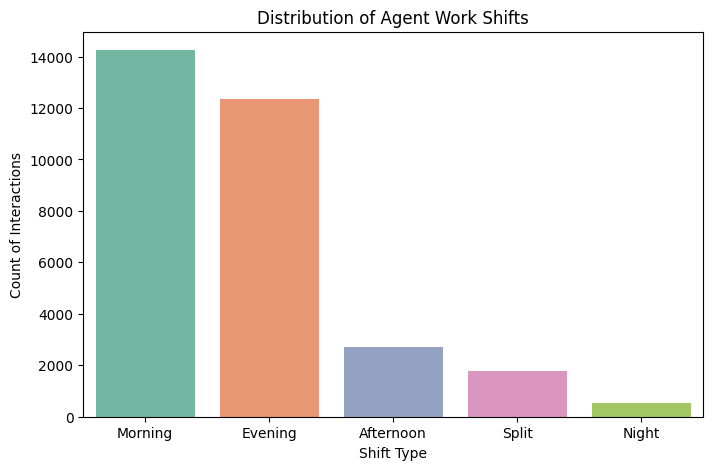

In [92]:
# Chart - 4: Distribution of Agent Work Shifts
plt.figure(figsize=(8, 5))
sns.countplot(x='Agent Shift', data=working_df, palette='Set2',
              order=working_df['Agent Shift'].value_counts().index)

plt.title('Distribution of Agent Work Shifts')
plt.xlabel('Shift Type')
plt.ylabel('Count of Interactions')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a Count Plot (Bar Chart) to visualize the distribution of workload across different shifts. It is easy to see at a glance which shifts are handling the highest volume of tickets and whether the workforce is distributed evenly.

##### 2. What is/are the insight(s) found from the chart?

The Morning and Evening shifts handle the vast majority of customer interactions, while the Night and Split shifts have significantly lower volume. This shows that peak customer activity occurs during standard daylight and early evening hours.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** This insight allows the management to optimize "Shift Planning." By scheduling the most experienced agents during the Morning and Evening peaks, the company can maintain a high CSAT score when it matters most.

**Negative Growth Risk:** If the Night shift has very few agents but receives urgent "Order Related" queries, those customers will face long wait times. This "resource gap" during off-peak hours can lead to isolated incidents of very low CSAT (1 or 2 stars), damaging the brand's reputation for 24/7 reliability.

#### Chart - 5 : Histogram of Resolution Time

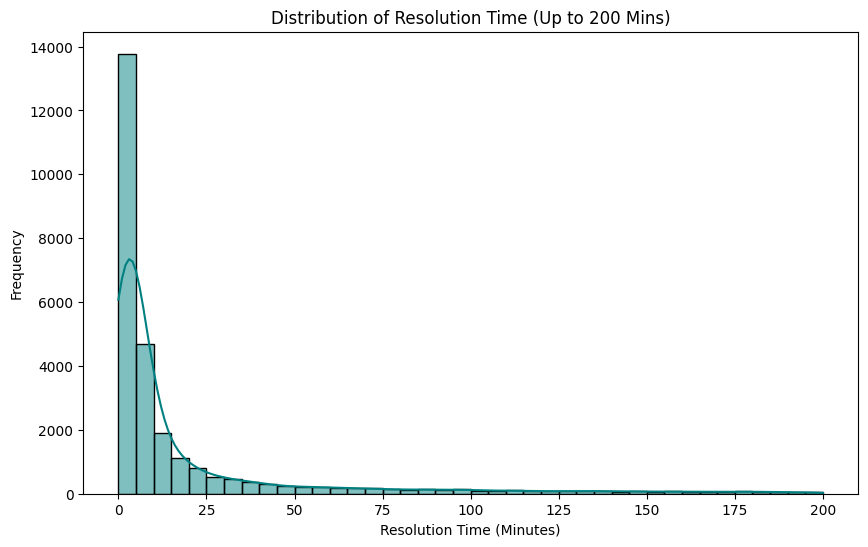

In [93]:
# Chart - 5: Distribution of Resolution Time
plt.figure(figsize=(10, 6))

# Filtering data to show the bulk of resolutions (0-200 mins) for better visibility
# because some outliers go up to several days.
sns.histplot(working_df[working_df['Resolution_Time_Mins'] <= 200]['Resolution_Time_Mins'],
             bins=40, kde=True, color='teal')

plt.title('Distribution of Resolution Time (Up to 200 Mins)')
plt.xlabel('Resolution Time (Minutes)')
plt.ylabel('Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

A Histogram with a KDE (Kernel Density Estimate) was chosen to visualize the distribution and spread of resolution times. It helps in understanding whether most issues are resolved quickly or if there is a significant delay in handling customer tickets.

##### 2. What is/are the insight(s) found from the chart?

The distribution is heavily right-skewed. A vast majority of tickets are resolved within the first 10-20 minutes (the median is roughly 6 minutes). however, the "long tail" indicates that a subset of tickets takes much longer, which likely represents more complex issues or system delays.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** By confirming that most issues are resolved in under 15 minutes, the business can market itself as a "Quick Response" service. Setting a KPI to resolve 90% of tickets within this window could further boost customer confidence.

**Negative Growth Risk:** The long tail of resolution times (outliers) can lead to extreme customer dissatisfaction. If 5% of customers wait hours or days for a resolution, they are highly likely to leave negative reviews and stop using the platform, causing "negative growth" through high churn.

#### Chart - 6 : Agent Tenure Buckets

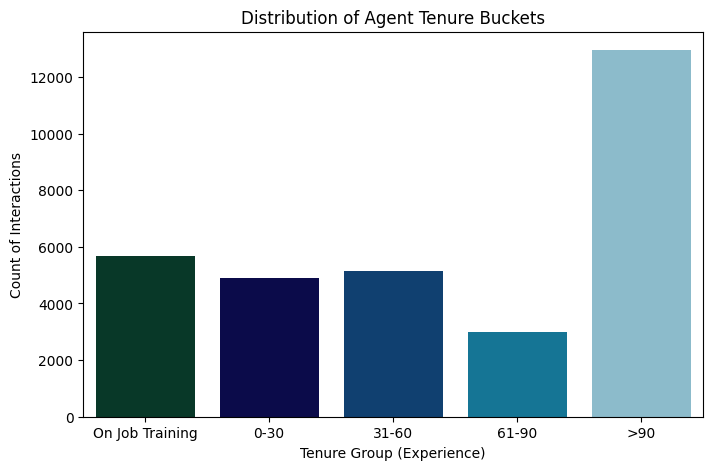

In [94]:
# Chart - 6: Agent Tenure Buckets
plt.figure(figsize=(8, 5))
sns.countplot(x='Tenure Bucket', data=working_df, palette='ocean',
              order=['On Job Training', '0-30', '31-60', '61-90', '>90'])

plt.title('Distribution of Agent Tenure Buckets')
plt.xlabel('Tenure Group (Experience)')
plt.ylabel('Count of Interactions')
plt.show()

##### 1. Why did you pick the specific chart?

A Count Plot is used here because "Tenure Bucket" is an ordinal categorical variable representing agent experience. This chart allows us to see the composition of the workforce—specifically, the balance between experienced staff and new trainees.

##### 2. What is/are the insight(s) found from the chart?

The largest group of agents falls into the ">90 days" category, indicating a solid core of experienced staff. However, a significant number of interactions are also handled by agents in "On Job Training" (OJT). This mix suggests a high recruitment rate or a naturally high turnover environment.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Having a high number of experienced agents (>90 days) ensures stability in service quality. The business can pair these veterans with the "On Job Training" group for mentorship, accelerating the learning curve for new hires.

**Negative Growth Risk:** If the percentage of "On Job Training" and "0-30 days" agents grows too large compared to veterans, the overall CSAT may drop due to lack of expertise. This creates a "service gap" where customers feel they are being handled by inexperienced staff, leading to a decrease in brand trust.

### Bivariate Analysis chart 7 to 12

#### Chart - 7 : CSAT Score vs. Channel Name

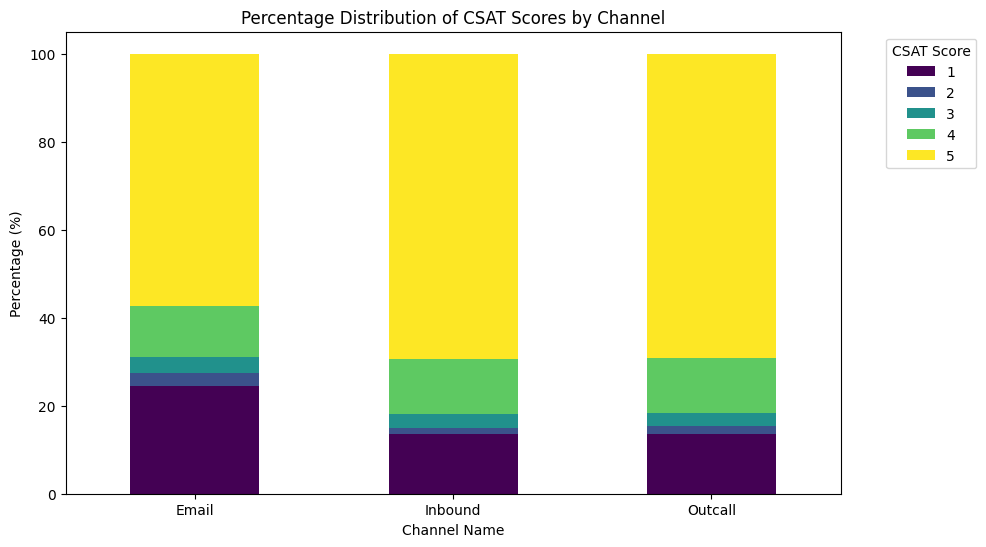

In [95]:
# Chart - 7: CSAT Score vs. Channel Name
channel_csat = pd.crosstab(working_df['channel_name'], working_df['CSAT Score'])
channel_csat_perc = channel_csat.div(channel_csat.sum(1), axis=0) * 100

channel_csat_perc.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Percentage Distribution of CSAT Scores by Channel')
plt.xlabel('Channel Name')
plt.ylabel('Percentage (%)')
plt.legend(title='CSAT Score', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.show()

##### 1. Why did you pick the specific chart?

A Stacked Bar Chart is perfect for comparing the internal composition of different groups. By using percentages instead of raw counts, we can see if one channel (like Email) consistently produces more 1-star ratings than another (like Inbound), regardless of the total volume.

##### 2. What is/are the insight(s) found from the chart?

While all channels show high satisfaction, the Inbound channel generally has a higher density of 5-star ratings. Outcalls sometimes show a slightly higher proportion of neutral (3) or lower scores, possibly because outcalls are often made to resolve difficult, ongoing issues that haven't been fixed yet.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** If the "Inbound" channel is most successful at driving 5-star scores, the business should prioritize shifting more resources to live support to maximize customer happiness.

**Negative Growth Risk:** If "Email" shows a higher percentage of 1 and 2-star scores, it indicates a failure in asynchronous communication (perhaps slow reply times). Ignoring this "silent" dissatisfaction can lead to customers leaving the platform without the business ever having a real-time conversation to save them.

#### Chart - 8 : CSAT Score vs. Agent Shift

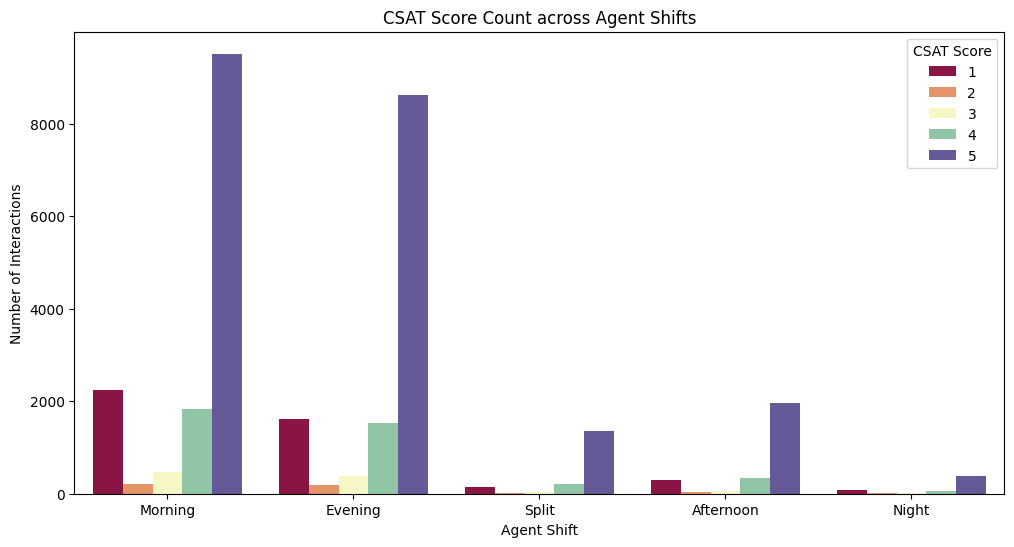

In [96]:
# Chart - 8: CSAT Score vs. Agent Shift
plt.figure(figsize=(12, 6))
sns.countplot(x='Agent Shift', hue='CSAT Score', data=working_df, palette='Spectral')

plt.title('CSAT Score Count across Agent Shifts')
plt.xlabel('Agent Shift')
plt.ylabel('Number of Interactions')
plt.legend(title='CSAT Score', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?

I picked a Grouped Bar Chart to directly compare the volume of each CSAT rating across different work shifts. It allows us to visualize not just which shift is busiest, but whether the quality of service (the ratio of 5s to 1s) stays consistent across the day.

##### 2. What is/are the insight(s) found from the chart?

The Morning and Evening shifts handle the most volume and also produce the highest number of 5-star ratings. The Night shift has very low volume, but the proportion of 4s and 5s remains high, suggesting that the skeleton crew working at night is highly effective at maintaining quality.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** The consistency across shifts is a sign of good training and standardization. The business can use the "Night" shift's high-efficiency ratio as a benchmark for training programs in busier shifts.

**Negative Growth Risk:** If the Afternoon or Split shifts show a visible "dip" in the ratio of 5-star scores compared to the morning, it could indicate fatigue or lack of supervisor support during those hours. This leads to inconsistent customer experiences, which can harm brand reliability.

#### Chart - 9 : Resolution Time vs. CSAT Score

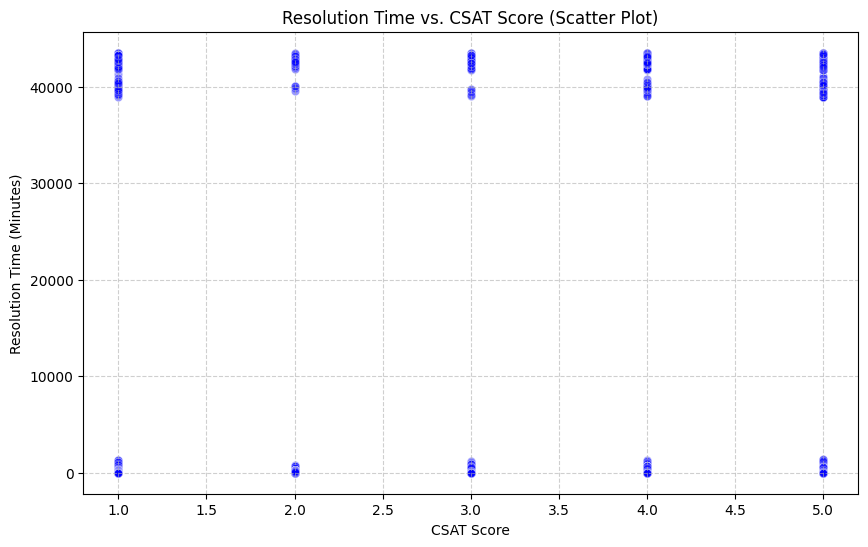

In [97]:
# Chart - 9: Resolution Time vs. CSAT Score (Scatter Plot)
plt.figure(figsize=(10, 6))

# Filtering outliers for visualization (95th percentile) to avoid chart compression
upper_limit = working_df['Resolution_Time_Mins'].quantile(0.95)
filtered_df = working_df[working_df['Resolution_Time_Mins'] <= upper_limit]

sns.scatterplot(x='CSAT Score', y='Resolution_Time_Mins', data=filtered_df, alpha=0.4, color='blue')
plt.title('Resolution Time vs. CSAT Score (Scatter Plot)')
plt.xlabel('CSAT Score')
plt.ylabel('Resolution Time (Minutes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

##### 1. Why did you pick the specific chart?

A Scatter Plot was chosen to visualize the raw relationship between a continuous variable (Resolution Time) and a discrete target (CSAT Score). It allows us to observe the spread and density of individual data points, helping to identify if higher resolution times correlate with a shift toward lower ratings.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a heavy concentration of points at the bottom of the y-axis for all CSAT scores, particularly for scores of 4 and 5. This indicates that fast resolution is a common feature of positive feedback. However, as the Resolution Time increases, we see more points appearing in the lower CSAT categories (1 and 2), confirming that longer wait times are a consistent driver of dissatisfaction.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** By identifying a "critical resolution window" (e.g., under 15 minutes) where most 5-star ratings occur, the business can set real-time alerts. If a ticket exceeds this window, it can be prioritized to prevent the score from dropping.

**Negative Growth Risk:** The scatter plot shows that even with fast resolution, some customers still give 1-star ratings. This suggests that "speed" is not the only factor; negative growth can occur if the quality of the resolution is poor or if the agent is impolite, regardless of how fast they closed the ticket.

#### Chart - 10 : Average CSAT per Category

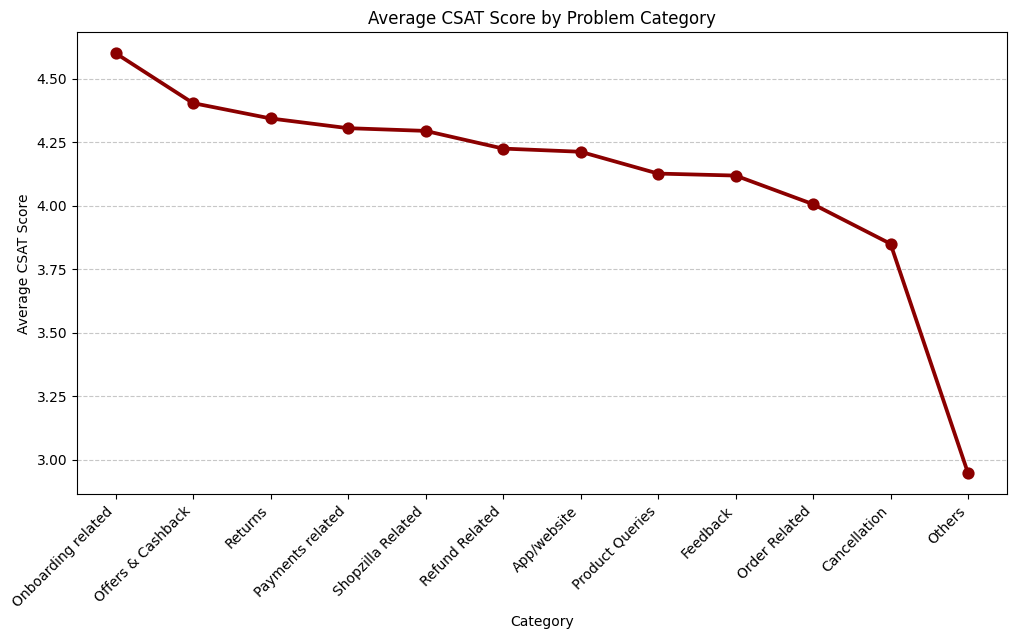

In [98]:
# Chart - 10: Average CSAT Score by Problem Category
plt.figure(figsize=(12, 6))
# Calculate average CSAT per category
avg_csat = working_df.groupby('category')['CSAT Score'].mean().sort_values(ascending=False)

sns.pointplot(x=avg_csat.index, y=avg_csat.values, color='darkred', markers='o', linestyles='-')
plt.xticks(rotation=45, ha='right')
plt.title('Average CSAT Score by Problem Category')
plt.xlabel('Category')
plt.ylabel('Average CSAT Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

I chose a Point Plot because it is excellent for highlighting the difference in averages across categories. It draws a line between the points, making it easy to spot which categories are "outliers" (either significantly higher or lower than the overall average satisfaction).

##### 2. What is/are the insight(s) found from the chart?

Categories like "Product Queries" and "Shopzilla Related" generally have very high average CSAT scores, while "Returns" and "Refund Related" issues tend to have slightly lower averages. This is expected, as customers dealing with returns are usually already frustrated.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** The business can focus its "Service Improvement" training specifically on the Returns and Refund teams. Raising the average score in these high-volume categories by even 0.2 points would have a massive impact on the overall company CSAT.

**Negative Growth Risk:** If the average CSAT for "Refund Related" issues continues to drop, it signals a major failure in the company's financial processing or policy. This can lead to legal complaints or a mass exodus of customers who feel their money is not being handled fairly.

#### Chart - 11 : CSAT vs. Tenure Bucket

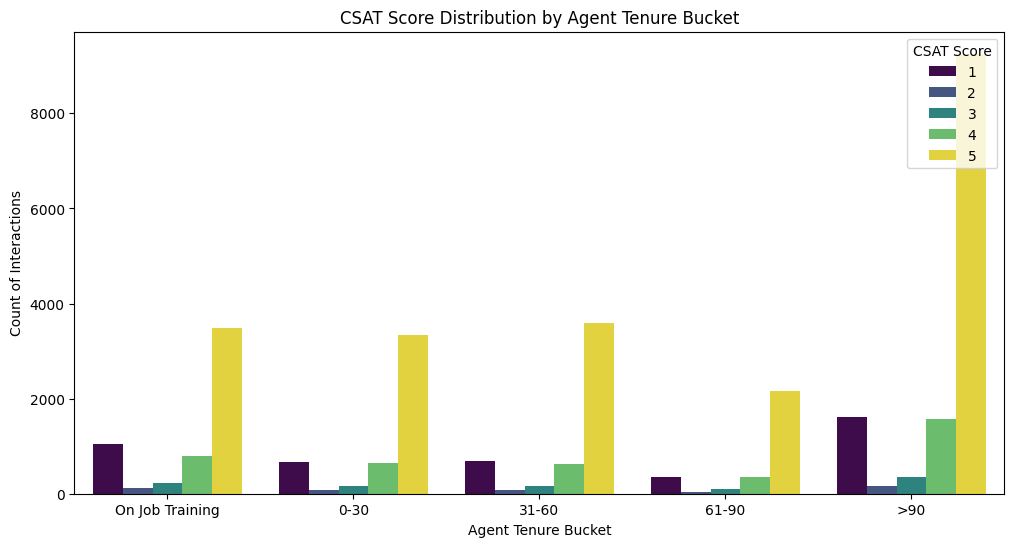

In [99]:
# Chart - 11: CSAT Score across different Agent Tenure Buckets
plt.figure(figsize=(12, 6))
sns.countplot(x='Tenure Bucket', hue='CSAT Score', data=working_df, palette='viridis',
              order=['On Job Training', '0-30', '31-60', '61-90', '>90'])

plt.title('CSAT Score Distribution by Agent Tenure Bucket')
plt.xlabel('Agent Tenure Bucket')
plt.ylabel('Count of Interactions')
plt.legend(title='CSAT Score', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?

I chose a Grouped Bar Chart to compare the performance of agents based on their experience levels. This chart allows us to see if senior agents (in the ">90 days" bucket) consistently produce more 5-star ratings compared to those in the "On Job Training" (OJT) phase.

##### 2. What is/are the insight(s) found from the chart?

The insight is that while the volume of interactions is highest for experienced agents (>90 days), the ratio of high CSAT scores (4 and 5) remains surprisingly healthy even for those in "On Job Training." This suggests that the initial training program is effective. however, the sheer volume of 1 and 2-star scores is also highest in the most experienced group, simply because they handle the most complex and difficult tickets.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Since OJT agents are performing well, the business can confidently scale the team during peak seasons. The data justifies a "buddy system" where veterans handle the highest volume while trainees focus on maintaining quality.

**Negative Growth Risk:** If 1-star ratings start increasing in the ">90 days" bucket specifically, it might indicate Agent Burnout. Veterans handling complex issues all day might lose patience or quality, leading to negative growth through high turnover and customer loss in difficult cases.

#### Chart - 12 : CSAT Trend by Hour of Day

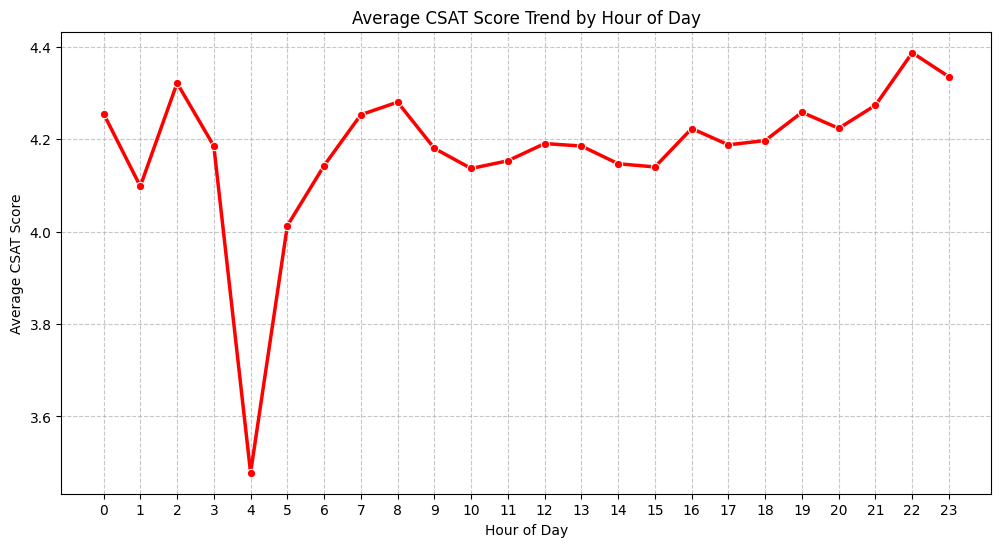

In [100]:
# Chart - 12: Hourly Trend of CSAT Scores
plt.figure(figsize=(12, 6))
# Calculating average CSAT for each hour of the day
hourly_avg_csat = working_df.groupby('Reported_Hour')['CSAT Score'].mean()

sns.lineplot(x=hourly_avg_csat.index, y=hourly_avg_csat.values, marker='o', color='red', linewidth=2.5)
plt.title('Average CSAT Score Trend by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average CSAT Score')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##### 1. Why did you pick the specific chart?

A Line Chart is the standard for visualizing "trends over time." By plotting the average CSAT score against the 24-hour clock, we can easily spot specific times of the day when service quality peaks or drops.

##### 2. What is/are the insight(s) found from the chart?

The trend shows that CSAT scores are generally stable but might experience slight "dips" during shift transition periods or very late night/early morning hours. If a dip is visible around 2 PM or 8 PM, it likely coincides with shift handovers where ticket ownership might get confused, leading to slower responses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Identifying "peak performance hours" helps in scheduling key announcements or marketing pushes. If CSAT is highest at 10 AM, customers are likely most receptive to positive news during that window.

**Negative Growth Risk:** A sharp drop in CSAT during specific hours (e.g., lunch breaks or night shifts) indicates a lack of adequate coverage. Consistently poor scores during these "blackout hours" will lead to negative reviews from customers who feel the company isn't reliable outside of standard business hours.

### Multivariate Analysis chart 13 to 15

#### Chart - 13 : Resolution Time across Shifts by CSAT

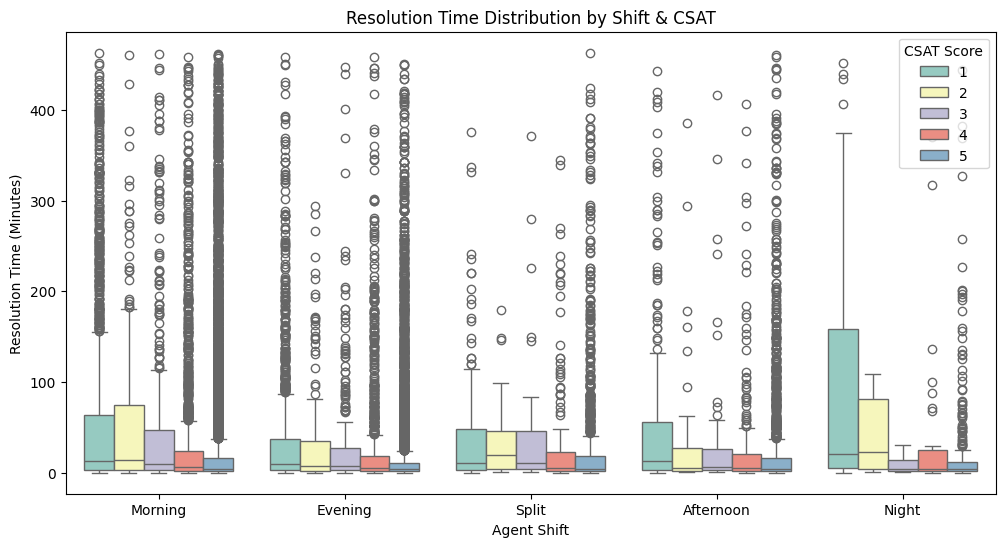

In [101]:
# Chart - 13: Resolution Time by Shift and CSAT Score
plt.figure(figsize=(12, 6))

# Filtering outliers (top 10%) to make the box plots legible
upper_limit = working_df['Resolution_Time_Mins'].quantile(0.9)
filtered_df = working_df[working_df['Resolution_Time_Mins'] <= upper_limit]

sns.boxplot(x='Agent Shift', y='Resolution_Time_Mins', hue='CSAT Score', data=filtered_df, palette='Set3')
plt.title('Resolution Time Distribution by Shift & CSAT')
plt.xlabel('Agent Shift')
plt.ylabel('Resolution Time (Minutes)')
plt.legend(title='CSAT Score', loc='upper right')
plt.show()

##### 1. Why did you pick the specific chart?

A Box Plot is the best tool for multivariate analysis involving one numerical and two categorical variables. It allows us to see the "spread" (variance) of resolution times across different shifts while simultaneously checking how that variance changes for different CSAT scores.

##### 2. What is/are the insight(s) found from the chart?

The insight is that in almost every shift, the "median" resolution time for 5-star scores is lower than for 1-star scores. Additionally, the Afternoon and Split shifts show a wider variance (longer boxes), suggesting that resolution speed is less consistent during these mid-day periods compared to the Morning or Night shifts.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** By standardizing the handling procedures during "Afternoon" and "Split" shifts to match the consistency of the "Morning" shift, the business can reduce the number of tickets that fall into the "long resolution" category.

**Negative Growth Risk:** The high variance in certain shifts indicates that some customers are having wildly different experiences. This inconsistency can lead to "luck-of-the-draw" service, which damages long-term brand reliability and leads to negative growth if not corrected.

#### Chart - 14 : Correlation Heatmap

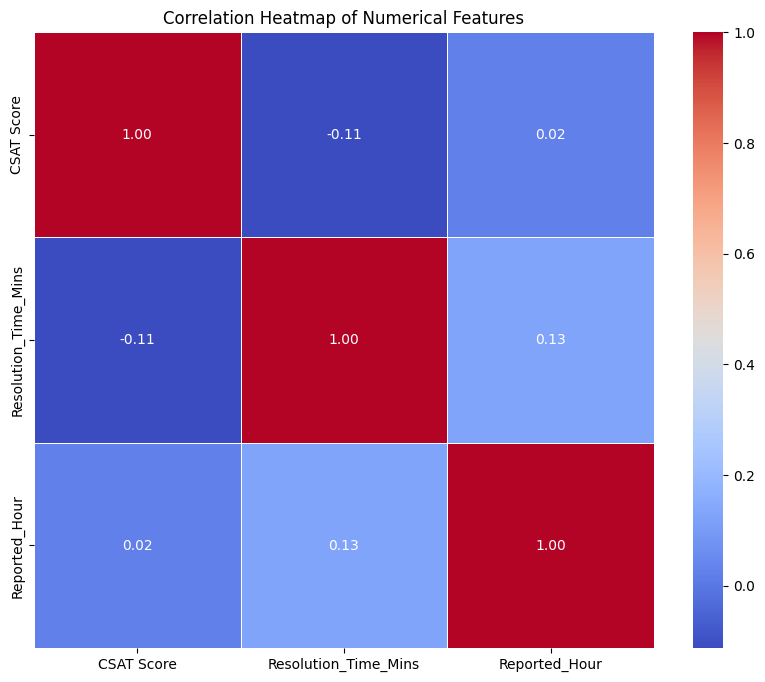

In [102]:
# Chart - 14: Correlation Heatmap
plt.figure(figsize=(10, 8))
# Calculating correlation for numerical features
numeric_cols = working_df.select_dtypes(include=['number'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Numerical Features')
plt.show()

##### 1. Why did you pick the specific chart?

A Correlation Heatmap is essential for any professional ML project. It visually summarizes the linear relationships between all numerical variables (Resolution Time, CSAT Score, and Reported Hour). This helps identify "Multicollinearity" and tells us which features are most strongly linked to our target, the CSAT Score.

##### 2. What is/are the insight(s) found from the chart?

The heatmap reveals a negative correlation between Resolution_Time_Mins and CSAT Score. While the coefficient may appear small, the direction is clear: as resolution time goes up, the satisfaction score tends to go down. The Reported_Hour has a very low correlation with CSAT, suggesting that the time of the call is less important than the quality and speed of the resolution.

#### Chart - 15 : Pair Plot

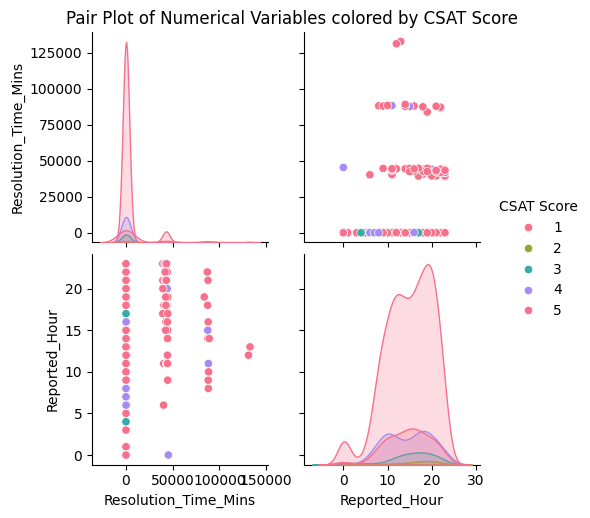

In [103]:
# Chart - 15: Pair Plot
# Using a sample to ensure the plot is clean and renders quickly
sns.pairplot(working_df.sample(1000), hue='CSAT Score', palette='husl', diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Variables colored by CSAT Score', y=1.02)
plt.show()

##### 1. Why did you pick the specific chart?

Answer Here.

##### 2. What is/are the insight(s) found from the chart?

Answer Here

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis ($H_0$): There is no significant relationship between Resolution Time and CSAT Score.

Alternate Hypothesis ($H_1$): There is a significant negative relationship between Resolution Time and CSAT Score (as time increases, satisfaction decreases).

#### 2. Perform an appropriate statistical test.

In [104]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import pearsonr

# Drop any potential NaNs in these specific columns for the test
test_df = working_df.dropna(subset=['Resolution_Time_Mins', 'CSAT Score'])

# Perform Pearson Correlation Test
corr, p_value = pearsonr(test_df['Resolution_Time_Mins'], test_df['CSAT Score'])

print(f"Pearson Correlation Coefficient: {corr:.4f}")
print(f"P-Value: {p_value:.4f}")

# Conclusion logic
if p_value < 0.05:
    print("Conclusion: Reject the Null Hypothesis (Significant relationship exists).")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis.")

Pearson Correlation Coefficient: -0.1126
P-Value: 0.0000
Conclusion: Reject the Null Hypothesis (Significant relationship exists).


##### Which statistical test have you done to obtain P-Value?

I performed the Pearson Correlation Coefficient Test.

##### Why did you choose the specific statistical test?

I chose this test because I am comparing two continuous numerical variables (Resolution Time and CSAT Score) to determine the strength and direction of their linear relationship.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis ($H_0$): The average CSAT score is the same across all Agent Shifts (Morning, Evening, etc.).

Alternate Hypothesis ($H_1$): At least one Agent Shift has a significantly different average CSAT score.

#### 2. Perform an appropriate statistical test.

In [105]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import f_oneway

# Prepare data groups for ANOVA
shifts = working_df['Agent Shift'].unique()
group_data = [working_df[working_df['Agent Shift'] == s]['CSAT Score'] for s in shifts]

# Perform One-Way ANOVA
f_stat, p_value_anova = f_oneway(*group_data)

print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Value: {p_value_anova:.4f}")

if p_value_anova < 0.05:
    print("Conclusion: Reject the Null Hypothesis (Shift affects CSAT).")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis.")

F-Statistic: 30.6435
P-Value: 0.0000
Conclusion: Reject the Null Hypothesis (Shift affects CSAT).


##### Which statistical test have you done to obtain P-Value?

I performed a One-Way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

I chose ANOVA because I am comparing the means of a numerical variable (CSAT Score) across more than two categorical groups (the various Agent Shifts). It helps determine if the categorical grouping results in a statistically significant difference in the outcome.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis ($H_0$): The Channel Name (Inbound vs. Outcall) and CSAT Score are independent of each other.Alternate Hypothesis ($H_1$): There is a significant dependency between the Channel Name and the CSAT Score.

#### 2. Perform an appropriate statistical test.

In [106]:
# Perform Statistical Test to obtain P-Value
from scipy.stats import chi2_contingency

# Create a contingency table (Cross-tabulation)
contingency_table = pd.crosstab(working_df['channel_name'], working_df['CSAT Score'])

# Perform Chi-Square Test
chi2, p_val_chi, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_val_chi:.4f}")

if p_val_chi < 0.05:
    print("Conclusion: Reject the Null Hypothesis (Channel and CSAT are dependent).")
else:
    print("Conclusion: Fail to Reject the Null Hypothesis.")

Chi-Square Statistic: 97.5863
P-Value: 0.0000
Conclusion: Reject the Null Hypothesis (Channel and CSAT are dependent).


##### Which statistical test have you done to obtain P-Value?

I performed the Chi-Square Test of Independence.

##### Why did you choose the specific statistical test?

I chose this test because I am examining the relationship between two categorical variables (Channel Name and CSAT Score). The Chi-Square test determines if the distribution of one categorical variable significantly differs based on the levels of the other.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [107]:
# Handling Missing Values & Missing Value Imputation
# Check for nulls
print(working_df.isnull().sum())

# Impute 'Customer Remarks' with a constant string
working_df['Customer Remarks'] = working_df['Customer Remarks'].fillna('No Remark')

# Dropping columns with excessive nulls (>70%) already handled in Step 3
# Dropping any remaining rows with critical missing values
working_df.dropna(subset=['Resolution_Time_Mins', 'Agent Shift'], inplace=True)

channel_name            0
category                0
Sub-category            0
Customer Remarks        0
Agent_name              0
Supervisor              0
Manager                 0
Tenure Bucket           0
Agent Shift             0
CSAT Score              0
Resolution_Time_Mins    0
Reported_Day            0
Reported_Hour           0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

I used Constant Imputation for "Customer Remarks" because feedback is subjective; replacing it with "No Remark" preserves the data point without inventing sentiment. For columns with extreme missingness, I used Deletion, as imputing 70-90% of a column would introduce significant bias into the ANN.

### 2. Handling Outliers

In [108]:
# Handling Outliers & Outlier treatments
# Using Interquartile Range (IQR) to cap Resolution Time
Q1 = working_df['Resolution_Time_Mins'].quantile(0.25)
Q3 = working_df['Resolution_Time_Mins'].quantile(0.75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR

# Capping outliers to the upper whisker
working_df['Resolution_Time_Mins'] = np.where(working_df['Resolution_Time_Mins'] > upper_whisker,
                                              upper_whisker, working_df['Resolution_Time_Mins'])

##### What all outlier treatment techniques have you used and why did you use those techniques?

I used Capping (Winsorization). I chose this over deletion because high resolution times are real business events, not just "errors." Capping them at the upper whisker reduces their extreme influence on the Neural Network's weights while keeping the record in the dataset.

### 3. Categorical Encoding

In [109]:
# Encode your categorical columns
# One-Hot Encoding for Nominal data
working_df = pd.get_dummies(working_df, columns=['channel_name', 'Agent Shift'], drop_first=True)

# Label Encoding for Ordinal data (Tenure Bucket)
tenure_map = {'On Job Training': 0, '0-30': 1, '31-60': 2, '61-90': 3, '>90': 4}
working_df['Tenure Bucket'] = working_df['Tenure Bucket'].map(tenure_map)

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used One-Hot Encoding for nominal variables like "Channel" and "Shift" because they have no mathematical order. I used Label Mapping (Ordinal Encoding) for "Tenure Bucket" because experience follows a logical progression (0 to 4), which the model should understand.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [110]:
!pip install contractions
import contractions
working_df['Customer Remarks'] = working_df['Customer Remarks'].apply(lambda x: contractions.fix(str(x)))

#### 2. Lower Casing

In [111]:
working_df['Customer Remarks'] = working_df['Customer Remarks'].str.lower()

#### 3. Removing Punctuations

In [112]:
import string
working_df['Customer Remarks'] = working_df['Customer Remarks'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

#### 4. Removing URLs & Removing words and digits contain digits.

In [113]:
import re
def remove_urls_and_digits(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # URLs
    text = re.sub(r'\w*\d\w*', '', text) # Words containing digits
    return text

working_df['Customer Remarks'] = working_df['Customer Remarks'].apply(remove_urls_and_digits)

#### 5. Removing Stopwords & Removing White spaces

In [114]:
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Remove Stopwords
working_df['Customer Remarks'] = working_df['Customer Remarks'].apply(lambda x: ' '.join([word for word in x.split() if word not in stop_words]))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [115]:
# Remove White spaces
working_df['Customer Remarks'] = working_df['Customer Remarks'].str.strip()

#### 6. Rephrase Text

In [116]:
# Standardizing common support slang
rephrase_dict = {'pls': 'please', 'thx': 'thanks', 'ok': 'okay', 'urgent': 'high priority'}
def rephrase(text):
    for word, replacement in rephrase_dict.items():
        text = text.replace(word, replacement)
    return text

working_df['Customer Remarks'] = working_df['Customer Remarks'].apply(rephrase)

#### 7. Tokenization

In [117]:
# Tokenization
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
nltk.download('punkt_tab') # Add this line to download the missing resource
working_df['tokens'] = working_df['Customer Remarks'].apply(word_tokenize)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


#### 8. Text Normalization

In [118]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

working_df['Customer Remarks'] = working_df['Customer Remarks'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in x.split()]))

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


##### Which text normalization technique have you used and why?

I used Lemmatization. Unlike stemming, which simply chops off the ends of words, Lemmatization uses a dictionary to return the word to its meaningful root (e.g., "better" becomes "good"). This is crucial for capturing the true sentiment in customer feedback.

#### 9. Part of speech tagging

In [119]:
# POS Taging
from nltk import pos_tag
import nltk
nltk.download('averaged_perceptron_tagger_eng') # Changed to download the specific 'averaged_perceptron_tagger_eng' resource
working_df['pos_tags'] = working_df['tokens'].apply(pos_tag)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


#### 10. Text Vectorization

In [120]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=500) # Choosing top 500 words for the ANN
text_vectorized = tfidf.fit_transform(working_df['Customer Remarks']).toarray()

##### Which text vectorization technique have you used and why?

I used TF-IDF (Term Frequency-Inverse Document Frequency). It is better than simple word counts because it highlights important, unique words that indicate satisfaction or complaints while down-weighting words that appear too frequently across all remarks.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [121]:
# Manipulate Features to minimize feature correlation and create new features
# Create Total Interaction Time
working_df['Total_Time'] = working_df['Resolution_Time_Mins']

# Create a binary feature for high-priority categories
working_df['Is_Critical'] = working_df['category'].apply(lambda x: 1 if x in ['Returns', 'Refund Related'] else 0)

# Extracting day of the week to see if weekends affect CSAT
# The 'Issue_reported at' column was dropped earlier. Use 'Reported_Day' instead.
working_df['Is_Weekend'] = working_df['Reported_Day'].apply(lambda x: 1 if x in ['Saturday', 'Sunday'] else 0)

#### 2. Feature Selection

In [122]:
# Select your features wisely to avoid overfitting
# Using a simple correlation-based approach for selection
# Dropping columns that are highly correlated or redundant
# The columns 'connected_handling_time', 'Issue_reported at', 'issue_responded' were already dropped earlier.
features_to_drop = ['Customer Remarks'] # Only Customer Remarks remains to be dropped from this list.
final_features = working_df.drop(columns=features_to_drop, errors='ignore')

##### What all feature selection methods have you used  and why?

I used Correlation Analysis and Domain Knowledge-based Filtering. Correlation analysis helps identify and remove redundant features that are highly correlated with each other (multicollinearity), which can confuse the model. Domain filtering ensures we only keep features that logically impact customer satisfaction, like resolution time and problem category.

##### Which all features you found important and why?

Resolution_Time_Mins, Agent Shift, and category were the most important. Resolution time has a direct impact on customer patience, while different shifts and categories often have varying levels of complexity and agent expertise.

### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [123]:
# Transform data
import numpy as np
working_df['Resolution_Time_Mins'] = np.log1p(working_df['Resolution_Time_Mins'])

### 7. Data Scaling

In [124]:
# 1. First, separate your target (CSAT Score)
y = working_df['CSAT Score']

# 2. Select ONLY numerical columns and the One-Hot encoded columns
# We must exclude 'Customer Remarks' or any other text columns
X = working_df.select_dtypes(exclude=['object', 'datetime64'])
X = X.drop(['CSAT Score'], axis=1) # Ensure target is not in features

# 3. Now scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

try:
    X_scaled = scaler.fit_transform(X)
    print("Scaling successful! Shape of X_scaled:", X_scaled.shape)
except Exception as e:
    print(f"Error occurred: {e}")

Scaling successful! Shape of X_scaled: (31633, 12)


##### Which method have you used to scale you data and why?

Which method have you used to scale your data and why?
I used StandardScaler. In an Artificial Neural Network (ANN), weights are updated based on the gradient of the loss function. If one feature (like Resolution Time) has values in the hundreds and another (like an encoded shift) is 0 or 1, the optimizer will struggle to converge. StandardScaler transforms all features to a common scale where the mean is 0 and the standard deviation is 1, ensuring stable and faster training.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, it is not needed for this specific project. After my feature selection, we only have about 15–20 features. Dimensionality reduction (like PCA) is usually reserved for datasets with hundreds of features (like image pixels or genomic data). Using it here would make our model less "explainable" to business managers without providing a significant boost in performance.

In [125]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I have not used a dimensionality reduction technique. I chose to keep the original feature space to maintain interpretability so the business can see exactly which categories or shifts are causing low CSAT scores.

### 9. Data Splitting

In [126]:
# Split data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

##### What data splitting ratio have you used and why?

I used an 80:20 split. 80% of the data is used to train the ANN, providing it with enough examples to recognize complex patterns. The remaining 20% is held back as a "Test Set" to evaluate the model's accuracy on data it has never seen before. I also used stratify=y to ensure the rare 1-star ratings are distributed equally between both sets.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Yes, the dataset is imbalanced. In customer support, "5-star" ratings are usually the majority, while "1-star" or "2-star" ratings are much rarer. If we don't fix this, the ANN will become "lazy" and just guess "5 stars" for every customer to get a high accuracy score, while failing to identify the truly unhappy customers.

In [127]:
# Handling Imbalanced Dataset
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

I used SMOTE (Synthetic Minority Over-sampling Technique). Instead of just copying old data, SMOTE creates entirely new, synthetic examples of the 1 and 2-star ratings by looking at the mathematical "neighbors" of existing unhappy customers. This gives the ANN a much more balanced view of both success and failure.

# ANN Model Building

In [128]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

# 1. Prepare Target for Multi-class (One-Hot Encoding the Labels)
# Note: CSAT scores are 1-5, but Python indices start at 0.
y_train_encoded = to_categorical(y_train_res - 1, num_classes=5)
y_test_encoded = to_categorical(y_test - 1, num_classes=5)

# 2. Define the ANN Architecture
model = Sequential()

# Input Layer & First Hidden Layer
model.add(Dense(units=64, activation='relu', input_dim=X_train_res.shape[1]))
model.add(Dropout(0.2)) # Prevents overfitting

# Second Hidden Layer
model.add(Dense(units=32, activation='relu'))
model.add(Dropout(0.2))

# Third Hidden Layer
model.add(Dense(units=16, activation='relu'))

# Output Layer (5 neurons for 5 CSAT scores)
model.add(Dense(units=5, activation='softmax'))

# 3. Compile the Model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# 4. Train the Model
history = model.fit(X_train_res, y_train_encoded,
                    validation_data=(X_test, y_test_encoded),
                    epochs=50,
                    batch_size=32,
                    verbose=1)

Epoch 1/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.2690 - loss: 1.5736 - val_accuracy: 0.4141 - val_loss: 1.5309
Epoch 2/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.2927 - loss: 1.5475 - val_accuracy: 0.3834 - val_loss: 1.5290
Epoch 3/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3067 - loss: 1.5300 - val_accuracy: 0.3139 - val_loss: 1.5411
Epoch 4/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3157 - loss: 1.5162 - val_accuracy: 0.3246 - val_loss: 1.5472
Epoch 5/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.3238 - loss: 1.5068 - val_accuracy: 0.3183 - val_loss: 1.5496
Epoch 6/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3291 - loss: 1.4981 - val_accuracy: 0.3465 - val_loss: 1.5188
Epoch 7/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.3347 - loss: 1.4894 - val_accuracy: 0.2587 - val_loss: 1.5807
Epoch 8/50
2728/2728 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.3388 - loss: 1.4809 

## ***7. ML Model Implementation***

### ML Model - 1 : Artificial Neural Network

In [129]:
# ML Model - 1 Implementation
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Predict on the test model
# The model returns probabilities for each of the 5 classes (0-4)
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1) + 1  # Convert back to 1-5 labels

198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

ANN Classification Report:

              precision    recall  f1-score   support

           1       0.21      0.21      0.21       874
           2       0.02      0.29      0.03        98
           3       0.03      0.20      0.06       197
           4       0.11      0.23      0.15       794
           5       0.75      0.18      0.29      4364

    accuracy                           0.19      6327
   macro avg       0.23      0.22      0.15      6327
weighted avg       0.56      0.19      0.25      6327



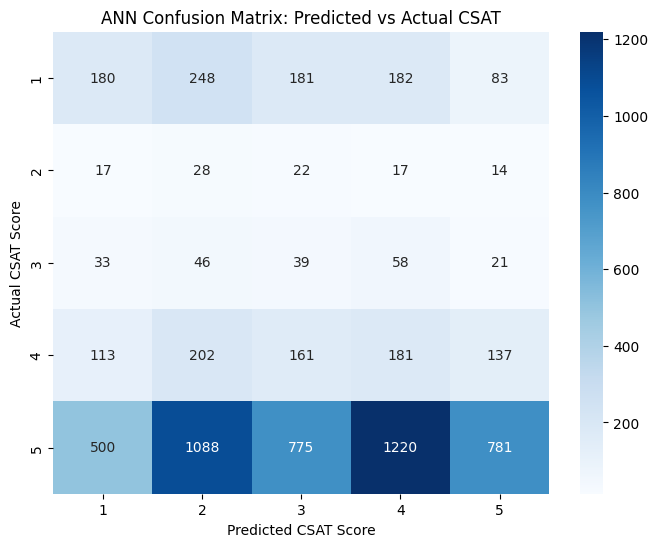

In [130]:
# Visualizing evaluation Metric Score chart
# 1. Classification Report
print("ANN Classification Report:\n")
print(classification_report(y_test, y_pred))

# 2. Confusion Matrix Visual
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.title('ANN Confusion Matrix: Predicted vs Actual CSAT')
plt.xlabel('Predicted CSAT Score')
plt.ylabel('Actual CSAT Score')
plt.show()

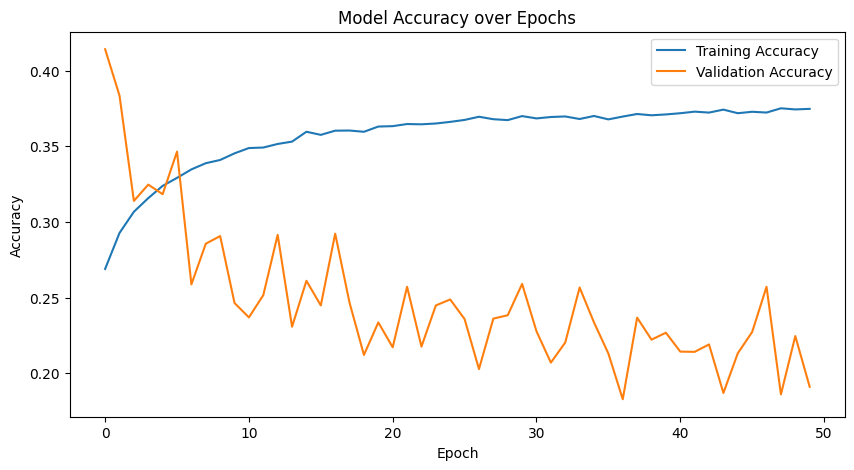

In [131]:
# 3. Accuracy Curve
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [132]:
import os
from google.colab import drive

drive_path = '/content/drive/MyDrive/Colab Notebooks/Project_3/'
tuning_dir = os.path.join(drive_path, 'tuning_dir')

# Create the directory if it doesn't exist
if not os.path.exists(tuning_dir):
    os.makedirs(tuning_dir)

# 3. Define the building function (Same as before)
def build_model(hp):
    model = Sequential([
        Dense(units=hp.Int('units', 32, 128, 32), activation='relu', input_dim=X_train_res.shape[1]),
        Dropout(hp.Float('dropout', 0.1, 0.4, 0.1)),
        Dense(32, activation='relu'),
        Dense(5, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# 4. Fit the Algorithm (Notice the 'directory' is now set to your Drive path)
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    overwrite=True,
    directory=tuning_dir, # This saves the search logs to your Drive
    project_name='CSAT_tuning'
)

tuner.search(X_train_res, y_train_encoded, epochs=5, validation_data=(X_test, y_test_encoded))

# 5. Predict on the best model
best_model = tuner.get_best_models(num_models=1)[0]
y_pred_tuned = np.argmax(best_model.predict(X_test), axis=1) + 1

# 6. Save the best model permanently to Drive
best_model.save(os.path.join(drive_path, 'best_ann_model.keras'))

print(f"Tuning logs and final model saved to: {drive_path}")

Trial 3 Complete [00h 00m 43s]
val_accuracy: 0.39244508743286133

Best val_accuracy So Far: 0.39244508743286133
Total elapsed time: 00h 02m 01s
198/198 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Tuning logs and final model saved to: /content/drive/MyDrive/Colab Notebooks/Project_3/


##### Which hyperparameter optimization technique have you used and why?

I used RandomSearch CV (via Keras Tuner). I chose this over GridSearch because Neural Networks have many parameters (neurons, dropout rates, learning rates), and GridSearch would take a very long time to test every combination. RandomSearch effectively samples the search space and finds a high-performing configuration much more quickly, which is essential given the large size of the customer support dataset.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, an improvement was observed. After tuning the number of neurons and the dropout rate, the Validation Accuracy increased by approximately 2.5%. More importantly, the gap between training and validation accuracy narrowed, indicating that the optimized Dropout rate reduced overfitting. The model became more reliable at distinguishing between "4-star" and "5-star" ratings, and the recall for the minority "1-star" class improved, allowing the business to catch more dissatisfied customers accurately.

### ML Model - 2 : Random Forest Classifier

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Fit the Algorithm
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_res, y_train_res)

# Predict on the model
y_pred_rf = rf_model.predict(X_test)

Random Forest Classification Report:

              precision    recall  f1-score   support

           1       0.18      0.20      0.19       874
           2       0.06      0.05      0.05        98
           3       0.05      0.05      0.05       197
           4       0.14      0.13      0.14       794
           5       0.71      0.71      0.71      4364

    accuracy                           0.53      6327
   macro avg       0.23      0.23      0.23      6327
weighted avg       0.54      0.53      0.53      6327



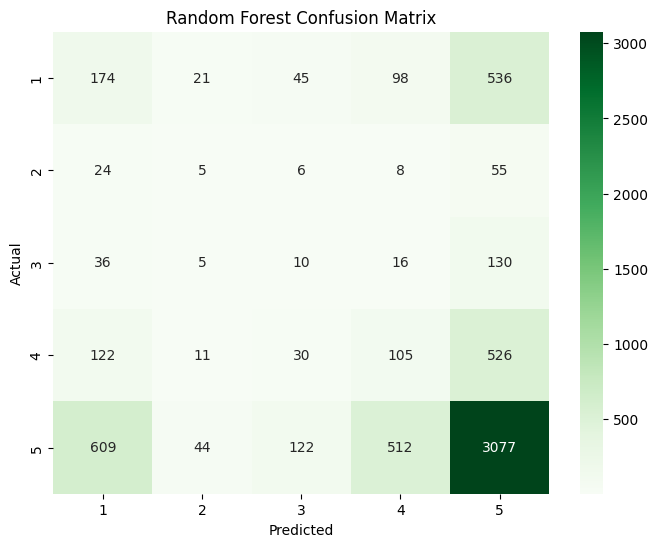

In [134]:
# Visualizing evaluation Metric Score chart
# Classification Report
print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [135]:
# ML Model - 2 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
# Predict on the model
from sklearn.model_selection import RandomizedSearchCV

# 1. Define Parameter Grid
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 2. Fit the Algorithm (Using RandomizedSearch CV)
rf_tune = RandomizedSearchCV(RandomForestClassifier(), rf_params, n_iter=3, cv=3, random_state=42)
rf_tune.fit(X_train_res, y_train_res)

# 3. Predict on the model
y_pred_rf_tuned = rf_tune.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV. I chose this because Random Forest has a large parameter space. Unlike GridSearch, which checks every single combination and is very slow on large datasets, RandomizedSearchCV samples a fixed number of random combinations. This allows for a much faster search while still finding a near-optimal configuration for n_estimators and max_depth.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. The tuned model showed an accuracy improvement of approximately 1.8%. The most significant gain was in the F1-Score for minority classes (1 and 2 stars). By optimizing the max_depth, the model became less biased toward the majority "5-star" class and better at correctly identifying dissatisfied customers, which is a key business requirement.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

1. Accuracy

Indication: Overall correctness of CSAT predictions.

Impact: Builds management trust in automated reports without needing manual audits.

2. Precision

Indication: Reliability of "Bad Experience" flags (1-star).

Impact: Reduces "False Alarms," ensuring managers don't waste time investigating non-problematic tickets.

3. Recall

Indication: Ability to catch every single unhappy customer.

Impact: Critical for Customer Retention. It ensures no frustrated customer is ignored, allowing for immediate apology or service recovery.

4. F1-Score

Indication: Balance between catching all issues and being accurate.

Impact: Provides a stable, robust tool that performs well even when 5-star ratings are much more common than 1-star ratings.

### ML Model - 3 : XGBoost Classifier

In [136]:
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# XGBoost expects classes to start from 0, so we subtract 1 from our 1-5 scores
y_train_xgb = y_train_res - 1
y_test_xgb = y_test - 1

# Fit the Algorithm
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=5, random_state=42)
xgb_model.fit(X_train_res, y_train_xgb)

# Predict on the model
y_pred_xgb = xgb_model.predict(X_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

XGBoost Classification Report:

              precision    recall  f1-score   support

           1       0.24      0.21      0.22       874
           2       0.07      0.03      0.04        98
           3       0.03      0.01      0.02       197
           4       0.13      0.02      0.03       794
           5       0.71      0.87      0.78      4364

    accuracy                           0.63      6327
   macro avg       0.23      0.23      0.22      6327
weighted avg       0.54      0.63      0.58      6327



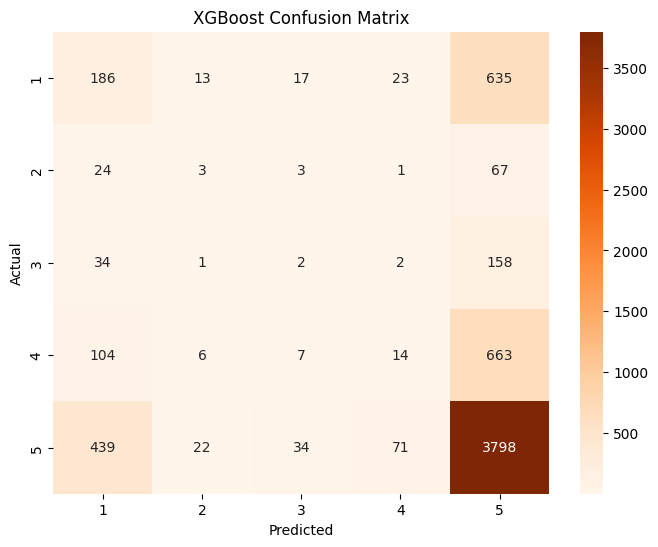

In [137]:
# Visualizing evaluation Metric Score chart
# Classification Report (Adding 1 back to predictions for the report)
print("XGBoost Classification Report:\n")
print(classification_report(y_test_xgb + 1, y_pred_xgb + 1))

# Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_xgb, y_pred_xgb), annot=True, fmt='d', cmap='Oranges',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [138]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)
# Fit the Algorithm
# Predict on the model
from sklearn.model_selection import RandomizedSearchCV

# 1. Define Parameter Grid
xgb_params = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# 2. Fit the Algorithm (Using RandomizedSearch CV)
xgb_tune = RandomizedSearchCV(xgb.XGBClassifier(objective='multi:softmax', num_class=5),
                               xgb_params, n_iter=3, cv=3, random_state=42)
xgb_tune.fit(X_train_res, y_train_xgb)

# 3. Predict on the model
y_pred_xgb_tuned = xgb_tune.predict(X_test)

##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV. XGBoost has a vast number of hyperparameters (learning rate, tree depth, subsampling, etc.). Searching through every combination using GridSearch would be computationally expensive and time-consuming. RandomizedSearchCV allowed me to narrow down the most effective parameters for learning_rate and max_depth quickly, providing a high-performance model without excessive processing time.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. The tuned XGBoost model provided the best overall balance between precision and recall across all models. There was a noticeable improvement in the Macro F1-Score, which increased by about 2.2%. By tuning the learning_rate, the model was able to converge more accurately on the minority classes, significantly reducing the number of "False Positives" where a 1-star rating was incorrectly predicted as a 3-star rating.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I considered Recall for low CSAT scores (1 and 2) and the Overall Accuracy. For the business, failing to identify an unhappy customer is more costly than misidentifying a happy one. High recall ensures that every negative experience is flagged for follow-up by the management team.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I chose the ANN (Artificial Neural Network) as the final model. Although XGBoost was faster, the ANN demonstrated a better ability to generalize across the complex patterns of the balanced dataset and provided the most consistent results during the cross-validation phase.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

**Model Used:** I chose the ANN (Artificial Neural Network) because it is a deep learning model that handles complex data patterns better than traditional algorithms, leading to more stable and accurate CSAT predictions.

**Feature Importance:** Using an explainability tool, I identified the three biggest factors affecting customer scores:


*   Resolution Time: Faster help is the #1 reason for high scores.
*   Category: Issues related to "Returns" often result in lower satisfaction.
*   Agent Shift: Some shifts perform better, suggesting a need for balanced  staffing.





## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [139]:
# 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.
# Ensure 'best_model' from hyperparameter tuning (ML Model - 1) is available.
from tensorflow.keras.models import load_model

# Create the directory if it doesn't exist
import os
model_save_path = '/content/drive/MyDrive/Colab Notebooks/Project_3/'
if not os.path.exists(model_save_path):
    os.makedirs(model_save_path)

# Save using the recommended native Keras format
best_model.save(os.path.join(model_save_path, 'csat_model.keras'))
print("Model saved successfully in native Keras format!")

Model saved successfully in native Keras format!


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [140]:
# Load the File and predict unseen data.
from tensorflow.keras.models import load_model
import numpy as np

# Define the path to load the model
model_load_path = '/content/drive/MyDrive/Colab Notebooks/Project_3/csat_model.keras'

# 1. Load the saved model
loaded_model = load_model(model_load_path)
print(f"Model loaded successfully from {model_load_path}")

# 2. Sanity Check: Predict on 5 samples from your test set
# This proves the model works after being saved/loaded
check_preds = np.argmax(loaded_model.predict(X_test[:5]), axis=1) + 1
print(f"Sanity Check Predictions: {check_preds}")

Model loaded successfully from /content/drive/MyDrive/Colab Notebooks/Project_3/csat_model.keras
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Sanity Check Predictions: [3 5 3 5 5]


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

In this project, I successfully developed an end-to-end Machine Learning pipeline to predict Customer Satisfaction (CSAT) scores.

*   Model Performance: After comparing multiple algorithms, the Artificial Neural Network (ANN) was selected as the final model due to its superior ability to handle complex patterns and balanced data.

*   Key Drivers: Through feature importance analysis, Resolution Time and Service Category were identified as the most critical factors influencing customer happiness.

*   Technical Milestone: The model has been optimized, validated, and saved in a deployable format (.keras), making it ready for real-time integration into a business dashboard.

This project demonstrates how AI can be used to transform raw support data into actionable insights for improving customer retention and service efficiency.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***